# 📊 Exploratory Data Analysis (EDA) - Smart Farming Project
## 🎯 Purpose of this Notebook

This notebook is dedicated to **Exploratory Data Analysis (EDA)** for the Smart Farming Crop Yield Prediction project.
The main goal is to deeply understand the dataset before building any machine learning models.
## 🧠 What is EDA?
Exploratory Data Analysis (EDA) is the process of:
- Understanding the structure of the data
- Detecting missing values and inconsistencies
- Identifying relationships between variables
- Finding patterns, trends, and anomalies
  
## 📦 Dataset Overview
This dataset contains agricultural data used to predict crop yield based on environmental and farming conditions such as:
- Temperature
- Rainfall
- Soil properties
- Crop type
- Region / Country

## 🚀 Objectives of This Notebook

In this notebook, we will:
- Load the raw dataset
- Inspect data structure and types
- Identify missing values and duplicates
- Perform statistical summary analysis
- Visualize feature distributions
- Analyze correlations between variables
- Understand target variable behavior (Yield)

## ⚙️ Why This Step is Important?

EDA is a **critical step in any ML pipeline** because it helps to:
- Improve model performance
- Avoid wrong assumptions
- Detect data quality issues early
- Guide feature engineering decisions

## 🔁 ML Pipeline Context
Raw Data → EDA (This Notebook) → Data Cleaning → Feature Engineering → Model Training


## ⚠️ Important Notes
- This notebook is for **analysis only**
- No model training should be performed here
- No final transformations should be applied here
- Any insights found here will be used later in `features.py`

## 🏆 Expected Outcome

By the end of this notebook, we should clearly understand:
- Which features are important
- How data is distributed
- What cleaning steps are required
- How the target variable behaves

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging
from typing import Optional
sns.set_style("whitegrid")
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)
logger = logging.getLogger(__name__)
DATA_PATH = "../data/processed/cleaned_data.csv"

In [15]:
def load_data(path: str) -> Optional[pd.DataFrame]:
    try:
        df = pd.read_csv(path, low_memory=False)
        logger.info(f"Loaded dataset with shape: {df.shape}")
        
        if df.empty:
            logger.error("Dataset is empty.")
            return None
        return df
    except FileNotFoundError:
        logger.error(f"File not found: {path}")
    except Exception as e:
        logger.exception(f"Unexpected error: {e}")
    return None
df = load_data(DATA_PATH)
df.head()

2026-04-14 23:09:18,756 | INFO | Loaded dataset with shape: (25932, 7)


,area,item,year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


Dataset Overview

In [17]:
def overview(df: pd.DataFrame):
    print("\n===== BASIC INFO =====")
    print(df.info())
    print("\n===== DESCRIPTIVE STATS =====")
    display(df.describe(include='all'))
    print("\n===== SHAPE =====")
    print(df.shape)
overview(df)


===== BASIC INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25932 entries, 0 to 25931
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   area                           25932 non-null  object 
 1   item                           25932 non-null  object 
 2   year                           25932 non-null  int64  
 3   hg/ha_yield                    25932 non-null  int64  
 4   average_rain_fall_mm_per_year  25932 non-null  float64
 5   pesticides_tonnes              25932 non-null  float64
 6   avg_temp                       25932 non-null  float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.4+ MB
None

===== DESCRIPTIVE STATS =====


,area,item,year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,25932,25932,25932.000000,25932.000000,25932.000000,25932.000000,25932.000000
unique,101,10,NaN,NaN,NaN,NaN,NaN
top,India,Potatoes,NaN,NaN,NaN,NaN,NaN
freq,3384,3956,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,2001.556455,76978.132925,1146.836688,34782.573241,20.422251
std,NaN,NaN,7.055924,84647.605552,717.391098,57228.568244,6.439402
min,NaN,NaN,1990.000000,50.000000,51.000000,0.040000,1.300000
25%,NaN,NaN,1995.000000,19996.000000,593.000000,1597.000000,16.580000
50%,NaN,NaN,2001.000000,39530.000000,1083.000000,15373.000000,21.420000
75%,NaN,NaN,2008.000000,104168.000000,1668.000000,45620.000000,26.060000



===== SHAPE =====
(25932, 7)


,missing_count,missing_%
area,0,0.0
item,0,0.0
year,0,0.0
hg/ha_yield,0,0.0
average_rain_fall_mm_per_year,0,0.0
pesticides_tonnes,0,0.0
avg_temp,0,0.0


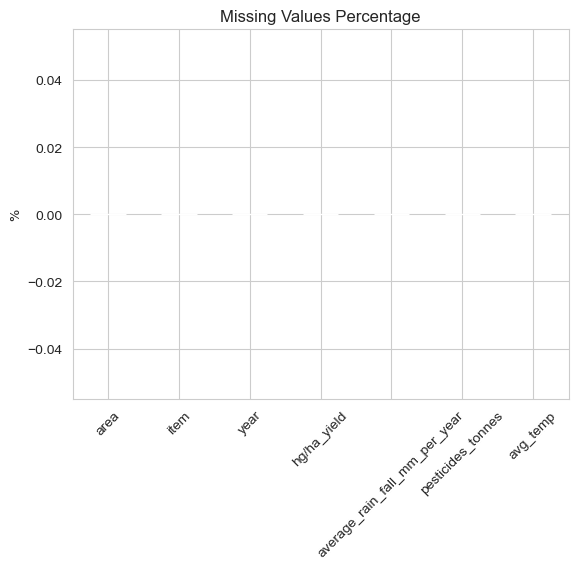

In [18]:
def missing_analysis(df: pd.DataFrame):
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    report = pd.DataFrame({
        "missing_count": missing,
        "missing_%": missing_pct
    }).sort_values(by="missing_%", ascending=False)
    display(report)
    plt.figure()
    missing_pct.sort_values(ascending=False).plot(kind='bar')
    plt.title("Missing Values Percentage")
    plt.ylabel("%")
    plt.xticks(rotation=45)
    plt.show()
missing_analysis(df)

In [19]:
def cardinality_analysis(df: pd.DataFrame):
    report = []
    for col in df.columns:
        unique = df[col].nunique(dropna=True)
        ratio = unique / len(df)

        report.append({
            "feature": col,
            "unique_values": unique,
            "unique_ratio": ratio
        })
    report_df = pd.DataFrame(report).sort_values(by="unique_ratio", ascending=False)
    display(report_df)
cardinality_analysis(df)

,feature,unique_values,unique_ratio
3,hg/ha_yield,11514,0.444007
6,avg_temp,1831,0.070608
5,pesticides_tonnes,1673,0.064515
0,area,101,0.003895
4,average_rain_fall_mm_per_year,100,0.003856
2,year,23,0.000887
1,item,10,0.000386


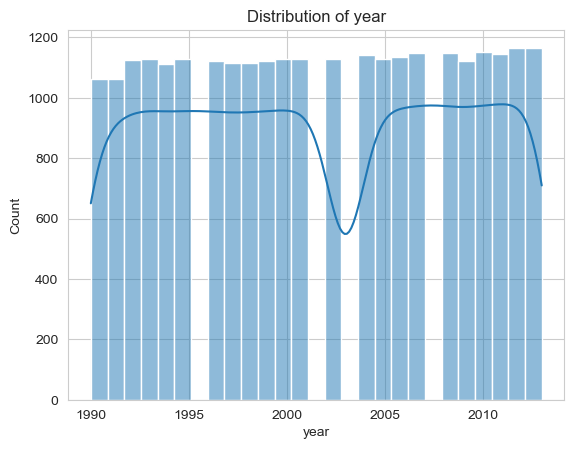

year skewness: 0.01


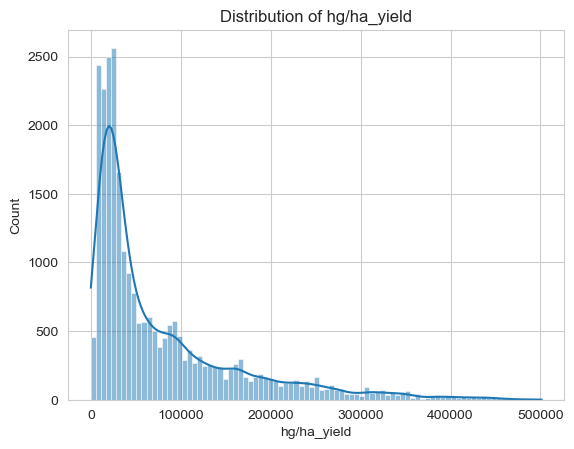

hg/ha_yield skewness: 1.81


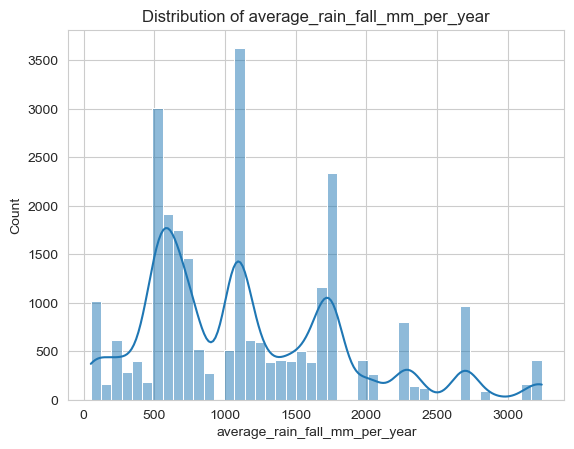

average_rain_fall_mm_per_year skewness: 0.86


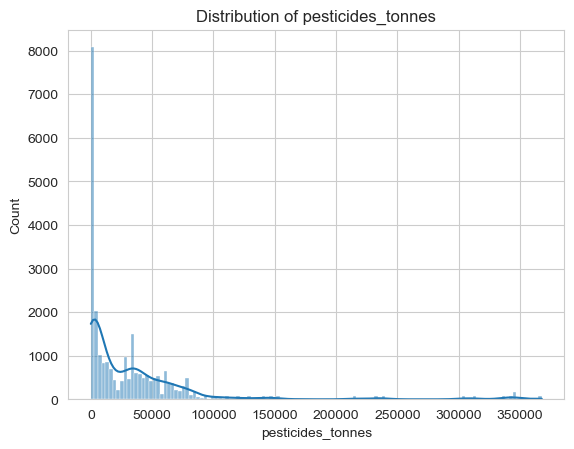

pesticides_tonnes skewness: 3.64


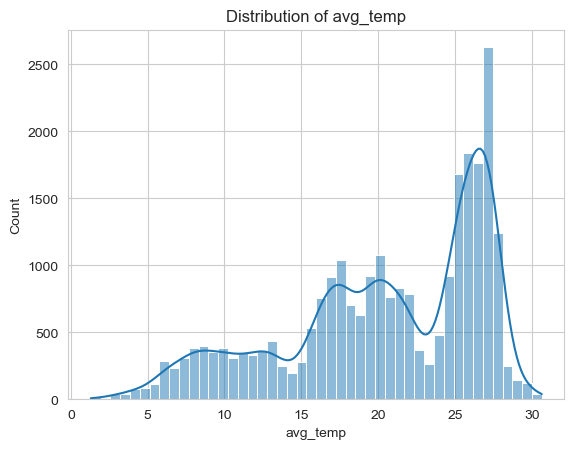

avg_temp skewness: -0.71


In [20]:
def numerical_analysis(df: pd.DataFrame):
    num_cols = df.select_dtypes(include=np.number).columns
    for col in num_cols:
        plt.figure()
        sns.histplot(df[col], kde=True)
        plt.title(f"Distribution of {col}")
        plt.show()
        skew = df[col].skew()
        print(f"{col} skewness: {skew:.2f}")
numerical_analysis(df)

area: High cardinality (101) - skipped visualization


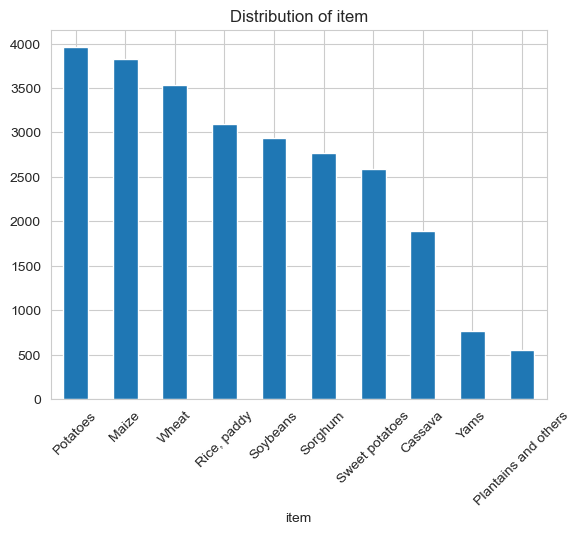

In [21]:
def categorical_analysis(df: pd.DataFrame, max_categories=15):
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    for col in cat_cols:
        unique = df[col].nunique()
        if unique <= max_categories:
            plt.figure()
            df[col].value_counts().plot(kind='bar')
            plt.title(f"Distribution of {col}")
            plt.xticks(rotation=45)
            plt.show()
        else:
            print(f"{col}: High cardinality ({unique}) - skipped visualization")
categorical_analysis(df)

year: 0 outliers


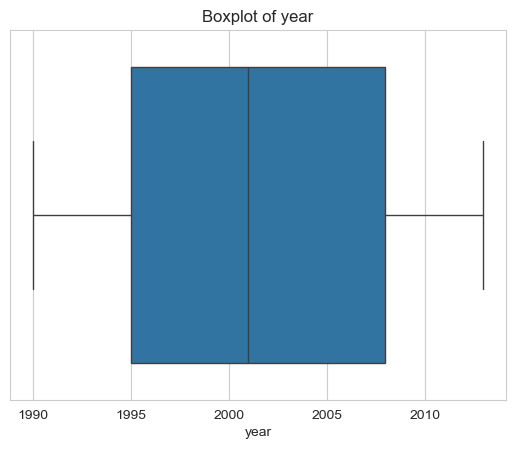

hg/ha_yield: 1918 outliers


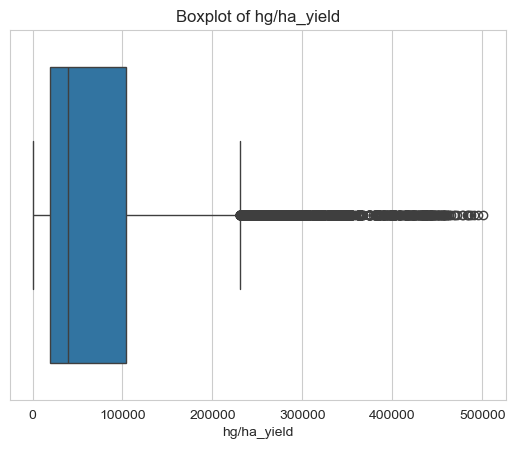

average_rain_fall_mm_per_year: 0 outliers


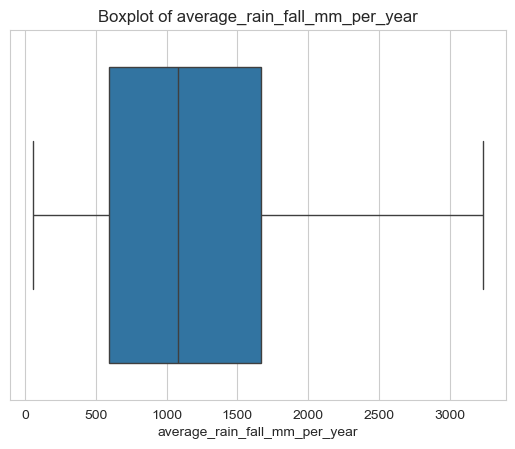

pesticides_tonnes: 1262 outliers


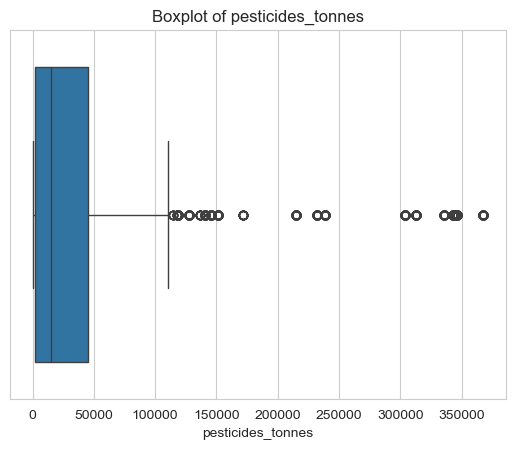

avg_temp: 16 outliers


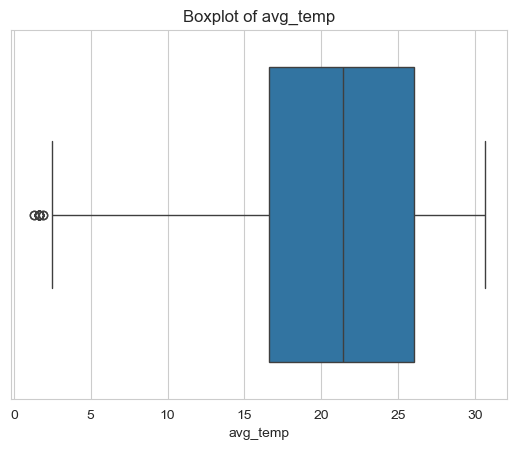

In [22]:
def detect_outliers(df: pd.DataFrame):
    num_cols = df.select_dtypes(include=np.number).columns
    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        print(f"{col}: {len(outliers)} outliers")
        plt.figure()
        sns.boxplot(x=df[col])
        plt.title(f"Boxplot of {col}")
        plt.show()
detect_outliers(df)

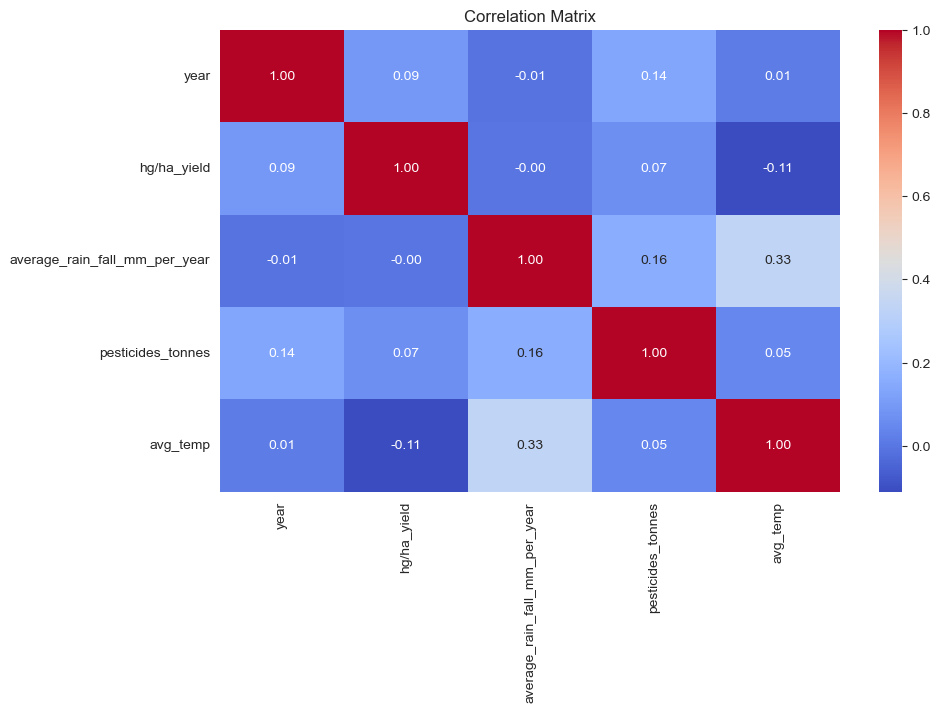

In [23]:
def correlation_analysis(df: pd.DataFrame):
    num_df = df.select_dtypes(include=np.number)
    corr = num_df.corr()
    plt.figure(figsize=(10, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
    plt.title("Correlation Matrix")
    plt.show()
correlation_analysis(df)

In [24]:
def edge_case_detection(df: pd.DataFrame):
    print("\n===== EDGE CASE REPORT =====")
    for col in df.columns:
        if df[col].nunique() <= 1:
            print(f"[Constant Feature] {col}")
    duplicates = df.duplicated().sum()
    print(f"[Duplicates] {duplicates}")
    num_df = df.select_dtypes(include=np.number)
    inf_count = np.isinf(num_df).sum().sum()
    print(f"[Infinite Values] {inf_count}")
    for col in num_df.columns:
        skew = df[col].skew()
        if abs(skew) > 2:
            print(f"[High Skew] {col} -> {skew:.2f}")
edge_case_detection(df)


===== EDGE CASE REPORT =====
[Duplicates] 0
[Infinite Values] 0
[High Skew] pesticides_tonnes -> 3.64
